# 🧠 Notebook 4: Holistic Health Model Training
## LAFIAKALO Holistic Health ML Model

**Purpose**: Train ML models to predict holistic health scores, detect risks, discover cross-domain correlations, and forecast health trends.

**Input**: `data/features/health_features.csv` from Notebook 03

**Models**:
1. **Holistic Health Score** — Composite score (0-100) based on all domains
2. **Risk Predictions** — Fluid overload, hyperkalemia, hypotension, malnutrition, hemolysis, anemia, calcification, GI distress, G6PD triggers, diabetes complications, depression
3. **Cross-Domain Correlations** — What drives what across domains
4. **Time-Series Forecasting** — Predict next lab values, weight trend
5. **Core ML Export** — Export best model as `.mlmodel` for on-device inference

**Algorithms**: XGBoost, LightGBM, Random Forest, Linear Regression, with SHAP explainability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             classification_report, roc_auc_score, confusion_matrix)
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    HAS_LGB = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    import coremltools as ct
    HAS_COREML = True
except Exception:
    HAS_COREML = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FEATURES_DIR = PROJECT_ROOT / 'data' / 'features'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"XGBoost: {'✅' if HAS_XGB else '❌ (libomp not installed — skipping)'}")
print(f"LightGBM: {'✅' if HAS_LGB else '❌'}")
print(f"SHAP: {'✅' if HAS_SHAP else '❌'}")
print(f"Core ML: {'✅' if HAS_COREML else '❌'}")

scikit-learn version 1.8.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.


XGBoost: ❌ (libomp not installed — skipping)
LightGBM: ❌
SHAP: ✅
Core ML: ✅


In [2]:
# Load features
df = pd.read_csv(FEATURES_DIR / 'health_features.csv', index_col='date', parse_dates=True)
print(f"Feature matrix: {df.shape[0]:,} days × {df.shape[1]} features")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")

# Load metadata
meta = pd.read_csv(FEATURES_DIR / 'feature_metadata.csv')
display(meta.head(10))

Feature matrix: 3,586 days × 347 features
Date range: 2016-04-28 → 2026-02-20


,feature,dtype,coverage,mean,std,min,max
0,dial_had_session,int64,1.000000,0.501115,0.500068,0.000000,1.000000
1,dial_sessions_count,int64,1.000000,0.501115,0.500068,0.000000,1.000000
2,dial_pre_weight,float64,0.477970,60.837465,4.973520,45.800000,72.000000
3,dial_post_weight,float64,0.456776,60.261214,14.508878,45.400000,614.000000
4,dial_weight_loss_kg,float64,0.453430,0.582747,14.231242,-551.800000,69.500000
5,dial_target_weight,float64,0.000837,49.566667,0.057735,49.500000,49.600000
6,dial_interdialytic_gain,float64,0.197434,-0.275282,20.801216,-552.500000,3.200000
7,dial_pre_bp_sys,float64,0.436698,124.255428,28.156249,61.000000,202.000000
8,dial_pre_bp_dia,float64,0.435862,80.545745,16.518361,39.000000,134.000000
9,dial_pre_map,float64,0.435304,95.082853,19.989808,47.666667,146.333333


---
## Part 1: Holistic Health Score

Build a composite health score (0–100) as a weighted combination of domain sub-scores.

### Approach
Since we don't have a pre-labeled "health score", we construct one using domain-specific indicators:
- **Dialysis effectiveness** (adequate UF, stable BP, session compliance)
- **Lab values in range** (BUN, K, Phos, Ca, Alb, Hgb within normal)
- **Nutrition adherence** (appropriate Na, K, Phos, protein intake)
- **Elimination health** (regular BMs, no vomiting, no blood)
- **Mood & sleep quality**
- **Vital stability** (BP not hyper/hypotensive, weight stable)
- **Physical activity**

In [3]:
def compute_holistic_score(df):
    """
    Compute holistic health score (0-100) as weighted average of domain sub-scores.
    Domain scores adapted to actual features from NB03.
    """
    scores = pd.DataFrame(index=df.index)
    
    # ═══════════════════════════════════════════
    # 1. DIALYSIS SCORE (0-100)
    # ═══════════════════════════════════════════
    dial_parts = []
    
    # Session compliance: ~5 sessions per week for HHD
    if 'dial_sessions_7d' in df.columns:
        compliance = (df['dial_sessions_7d'] / 5).clip(0, 1) * 100
        dial_parts.append(compliance)
    
    # Weight loss (fluid removal): 0.5-3 kg is typical for HHD
    if 'dial_weight_loss_kg' in df.columns:
        wl = df['dial_weight_loss_kg']
        wl_score = pd.Series(50.0, index=df.index)
        wl_score = np.where((wl >= 0.5) & (wl <= 3), 90, wl_score)
        wl_score = np.where(wl > 3, 60, wl_score)
        wl_score = np.where((wl >= 0) & (wl < 0.5), 70, wl_score)
        dial_parts.append(pd.Series(wl_score, index=df.index, dtype=float))
    
    # Kt/V adequacy (>1.2 is adequate)
    if 'dial_ktv_actual' in df.columns:
        ktv = df['dial_ktv_actual']
        ktv_score = np.where(ktv >= 1.4, 95, np.where(ktv >= 1.2, 80, np.where(ktv >= 1.0, 50, 30)))
        dial_parts.append(pd.Series(ktv_score, index=df.index, dtype=float))
    
    # BP stability: small BP drop = good, large drop = bad
    if 'dial_bp_drop_sys' in df.columns:
        drop = df['dial_bp_drop_sys'].abs()
        bp_score = np.where(drop < 20, 90, np.where(drop < 40, 60, 30))
        dial_parts.append(pd.Series(bp_score, index=df.index, dtype=float))
    
    if dial_parts:
        scores['score_dialysis'] = pd.concat(dial_parts, axis=1).mean(axis=1)
    
    # ═══════════════════════════════════════════
    # 2. LAB SCORE (0-100)
    # ═══════════════════════════════════════════
    lab_scores = []
    zscore_cols = [c for c in df.columns if c.endswith('_zscore')]
    for col in zscore_cols:
        z = df[col].abs()
        lab_scores.append(100 - (z * 25).clip(0, 100))
    
    if lab_scores:
        scores['score_labs'] = pd.concat(lab_scores, axis=1).mean(axis=1)
    
    # ═══════════════════════════════════════════
    # 3. NUTRITION SCORE (0-100)
    # ═══════════════════════════════════════════
    nutr_parts = []
    RENAL_LIMITS = {
        'nutr_sodium_mg':     (500, 2000),
        'nutr_potassium_mg':  (1500, 2700),
        'nutr_phosphorus_mg': (400, 800),
        'nutr_protein_g':     (50, 80),
        'nutr_calories':      (1500, 2500),
    }
    for col, (low, high) in RENAL_LIMITS.items():
        if col in df.columns:
            val = df[col]
            score = np.where((val >= low) & (val <= high), 90,
                    np.where(val < low, (val / low * 60).clip(0, 60),
                             (60 - (val - high) / high * 30).clip(0, 60)))
            nutr_parts.append(pd.Series(score, index=df.index, dtype=float))
    
    if 'nutr_logged_today' in df.columns:
        nutr_parts.append(df['nutr_logged_today'] * 80 + 20)
    
    if nutr_parts:
        scores['score_nutrition'] = pd.concat(nutr_parts, axis=1).mean(axis=1)
    
    # ═══════════════════════════════════════════
    # 4. ELIMINATION SCORE (0-100)
    # ═══════════════════════════════════════════
    elim_parts = []
    if 'elim_gi_health' in df.columns:
        elim_parts.append(df['elim_gi_health'] * 100)
    else:
        if 'elim_bowel_count' in df.columns:
            bm = df['elim_bowel_count']
            elim_parts.append(pd.Series(
                np.where((bm >= 1) & (bm <= 3), 90, np.where(bm == 0, 40, 60)),
                index=df.index, dtype=float))
        if 'elim_vomit_count' in df.columns:
            elim_parts.append((1 - df['elim_vomit_count'].clip(0, 3) / 3) * 100)
    if elim_parts:
        scores['score_elimination'] = pd.concat(elim_parts, axis=1).mean(axis=1)
    
    # ═══════════════════════════════════════════
    # 5. MOOD & SLEEP SCORE (0-100)
    # ═══════════════════════════════════════════
    mood_parts = []
    if 'mood_score' in df.columns:
        mood_parts.append(df['mood_score'].clip(1, 10) * 10)
    if 'mood_sleep_hours' in df.columns:
        sh = df['mood_sleep_hours']
        mood_parts.append(pd.Series(
            np.where((sh >= 7) & (sh <= 9), 90, np.where((sh >= 5) & (sh < 7), 65, 40)),
            index=df.index, dtype=float))
    if mood_parts:
        scores['score_mood_sleep'] = pd.concat(mood_parts, axis=1).mean(axis=1)
    
    # ═══════════════════════════════════════════
    # 6. VITALS SCORE (0-100)
    # ═══════════════════════════════════════════
    vital_parts = []
    # Use dialysis BP as primary vitals source (much more data)
    bp_sys = df.get('dial_pre_bp_sys', df.get('vitals_med_bp_sys'))
    if bp_sys is not None:
        vital_parts.append(pd.Series(
            np.where((bp_sys >= 90) & (bp_sys <= 140), 90,
            np.where((bp_sys >= 80) & (bp_sys <= 160), 60, 30)),
            index=df.index, dtype=float))
    if vital_parts:
        scores['score_vitals'] = pd.concat(vital_parts, axis=1).mean(axis=1)
    
    # ═══════════════════════════════════════════
    # 7. ACTIVITY SCORE (0-100) — from dialysis schedule
    # ═══════════════════════════════════════════
    if 'activity_active_days_7d' in df.columns:
        scores['score_activity'] = (df['activity_active_days_7d'] / 5).clip(0, 1) * 100
    
    # ═══════════════════════════════════════════
    # COMPOSITE HOLISTIC SCORE
    # ═══════════════════════════════════════════
    WEIGHTS = {
        'score_dialysis':     0.25,
        'score_labs':         0.25,
        'score_nutrition':    0.15,
        'score_elimination':  0.10,
        'score_mood_sleep':   0.10,
        'score_vitals':       0.10,
        'score_activity':     0.05,
    }
    
    available = [c for c in WEIGHTS if c in scores.columns]
    total_w = sum(WEIGHTS[c] for c in available)
    norm_w = {c: WEIGHTS[c] / total_w for c in available}
    
    holistic = pd.Series(0.0, index=df.index)
    for col, w in norm_w.items():
        holistic += scores[col].fillna(50) * w
    
    scores['holistic_score'] = holistic.clip(0, 100)
    return scores

health_scores = compute_holistic_score(df)
print(f"Computed {health_scores.shape[1]} score columns:")
for col in health_scores.columns:
    valid = health_scores[col].notna().sum()
    print(f"  {col:25s} mean={health_scores[col].mean():.1f}  ({valid:,} days)")
print(health_scores.describe().round(1).to_string())

Computed 8 score columns:
  score_dialysis            mean=52.3  (3,586 days)
  score_labs                mean=82.4  (3,568 days)
  score_nutrition           mean=19.6  (3,586 days)
  score_elimination         mean=43.2  (3,586 days)
  score_mood_sleep          mean=40.0  (3,586 days)
  score_vitals              mean=48.9  (3,586 days)
  score_activity            mean=68.5  (3,586 days)
  holistic_score            mean=53.2  (3,586 days)
       score_dialysis  score_labs  score_nutrition  score_elimination  score_mood_sleep  score_vitals  score_activity  holistic_score
count          3586.0      3568.0           3586.0             3586.0            3586.0        3586.0          3586.0          3586.0
mean             52.3        82.4             19.6               43.2              40.0          48.9            68.5            53.2
std              15.0         4.4              8.4               22.0               1.0          25.8            32.7             7.3
min              27.5 

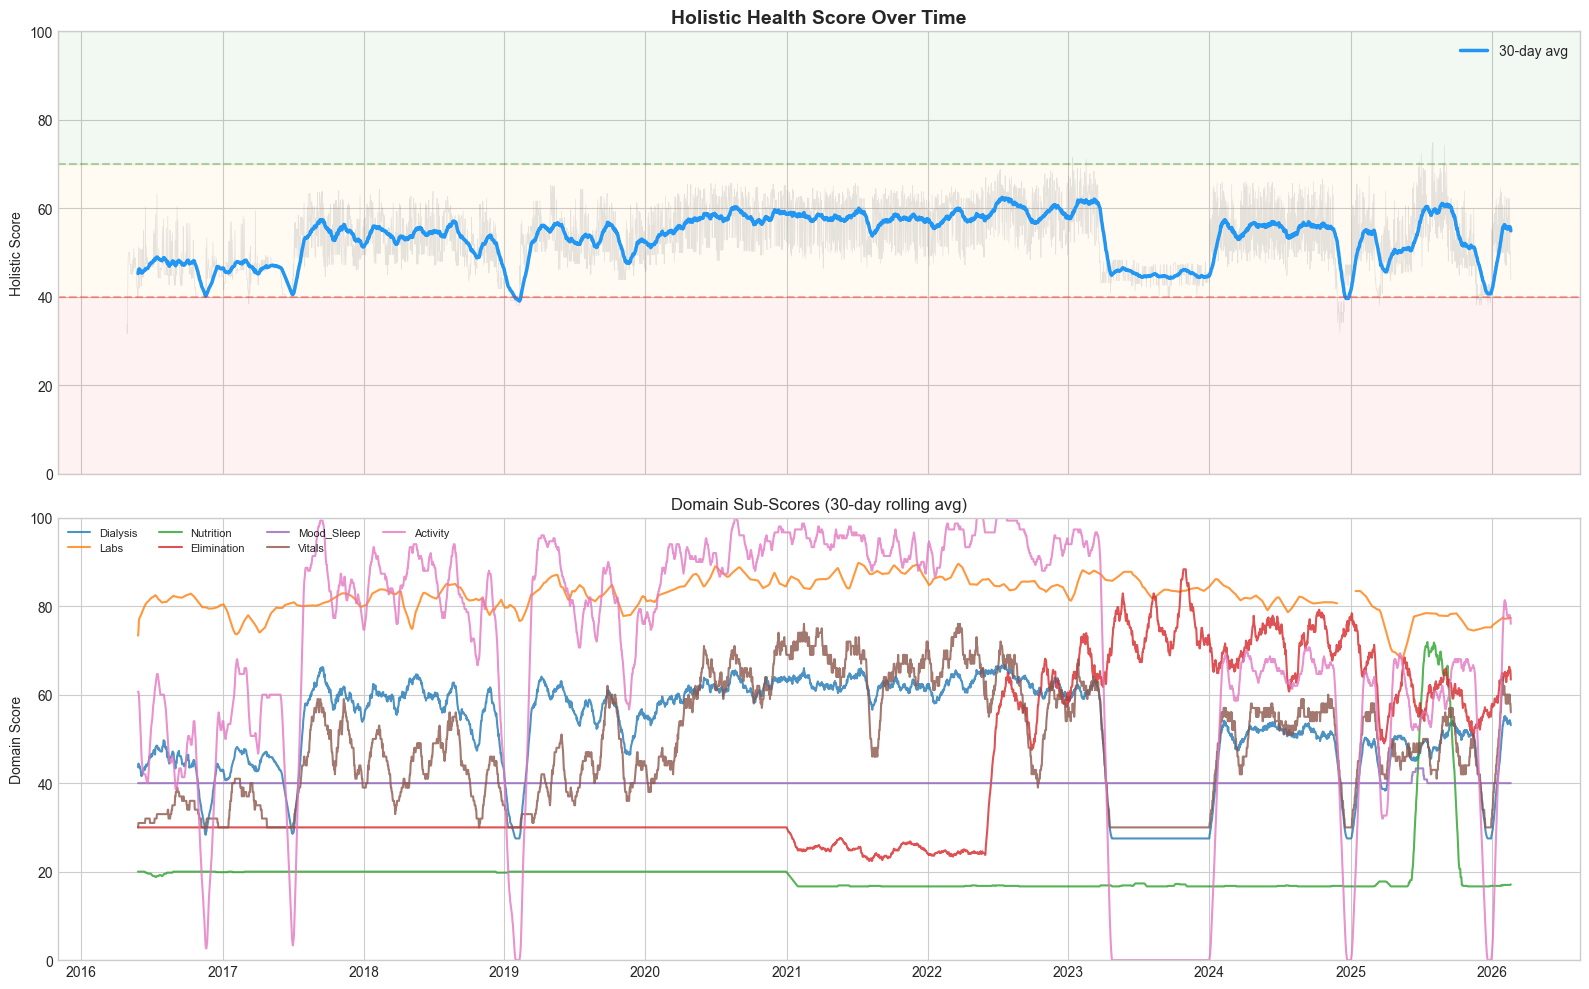

In [4]:
# Visualize holistic score over time
if 'holistic_score' in health_scores.columns:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    # Main holistic score
    ax = axes[0]
    score = health_scores['holistic_score'].dropna()
    ax.plot(score.index, score.values, alpha=0.2, linewidth=0.5, color='gray')
    rolling = score.rolling(30).mean()
    ax.plot(rolling.index, rolling.values, linewidth=2.5, color='#2196F3', label='30-day avg')
    ax.axhspan(70, 100, alpha=0.05, color='green')
    ax.axhspan(40, 70, alpha=0.05, color='orange')
    ax.axhspan(0, 40, alpha=0.05, color='red')
    ax.set_ylabel('Holistic Score')
    ax.set_ylim(0, 100)
    ax.set_title('Holistic Health Score Over Time', fontsize=14, fontweight='bold')
    ax.legend()
    ax.axhline(70, color='green', linestyle='--', alpha=0.3)
    ax.axhline(40, color='red', linestyle='--', alpha=0.3)
    
    # Sub-scores
    ax = axes[1]
    sub_scores = [c for c in health_scores.columns if c.startswith('score_')]
    for col in sub_scores:
        rolling = health_scores[col].rolling(30).mean()
        ax.plot(rolling.index, rolling.values, linewidth=1.5, alpha=0.8,
                label=col.replace('score_', '').title())
    ax.set_ylabel('Domain Score')
    ax.set_ylim(0, 100)
    ax.set_title('Domain Sub-Scores (30-day rolling avg)', fontsize=12)
    ax.legend(loc='upper left', ncol=4, fontsize=8)
    
    plt.tight_layout()
    plt.show()

---
## Part 2: Train Predictive Models

### Model A: Predict Holistic Health Score
Given today's features, predict the holistic score.

In [5]:
# Prepare training data
# Target: holistic_score (computed above)
# Features: original health features

target = health_scores['holistic_score']

# Drop temporal features that would leak info
feature_cols = [c for c in df.columns if c not in ['temp_days_from_start', 'temp_year']]

# Join features + target, drop rows with no target
train_data = df[feature_cols].join(target).dropna(subset=['holistic_score'])

X = train_data[feature_cols]
y = train_data['holistic_score']

print(f"Training samples: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"Target range: {y.min():.1f} – {y.max():.1f}")
print(f"Target mean: {y.mean():.1f} ± {y.std():.1f}")

# Remove features with >50% missing
coverage = X.notna().mean()
good_cols = coverage[coverage > 0.1].index.tolist()
X = X[good_cols]
print(f"\nFeatures with >10% coverage: {len(good_cols)}")

Training samples: 3,586
Features: 345
Target range: 31.7 – 74.8
Target mean: 53.2 ± 7.3

Features with >10% coverage: 284


In [6]:
# Time-series cross-validation (respect temporal order)
tscv = TimeSeriesSplit(n_splits=5)

# Build preprocessing pipeline
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

# ═══════════════════════════════════════════════════
# Model comparison
# ═══════════════════════════════════════════════════
models = {
    'Ridge': Ridge(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
}

if HAS_XGB:
    models['XGBoost'] = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        tree_method='hist'
    )

if HAS_LGB:
    models['LightGBM'] = lgb.LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        verbose=-1
    )

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model),
    ])
    
    # Cross-validate
    rmse_scores = []
    mae_scores = []
    r2_scores = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        
        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        r2_scores.append(r2_score(y_test, y_pred))
    
    results[name] = {
        'RMSE': np.mean(rmse_scores),
        'MAE': np.mean(mae_scores),
        'R²': np.mean(r2_scores),
    }
    print(f"  {name:20s} RMSE={np.mean(rmse_scores):.2f}  MAE={np.mean(mae_scores):.2f}  R²={np.mean(r2_scores):.3f}")

results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print("\n" + "="*60)
display(results_df)

  Ridge                RMSE=142.91  MAE=60.06  R²=-2519.763
  ElasticNet           RMSE=5.09  MAE=3.57  R²=0.278
  RandomForest         RMSE=3.13  MAE=2.39  R²=0.782
  GradientBoosting     RMSE=2.74  MAE=2.05  R²=0.832



,RMSE,MAE,R²
GradientBoosting,2.736428,2.045214,0.832065
RandomForest,3.127552,2.394899,0.781589
ElasticNet,5.086908,3.574018,0.278126
Ridge,142.906371,60.057126,-2519.763122



Best model: GradientBoosting (R²=0.832)

Final test (last 20%):
  RMSE: 3.97
  MAE:  2.65
  R²:   0.742


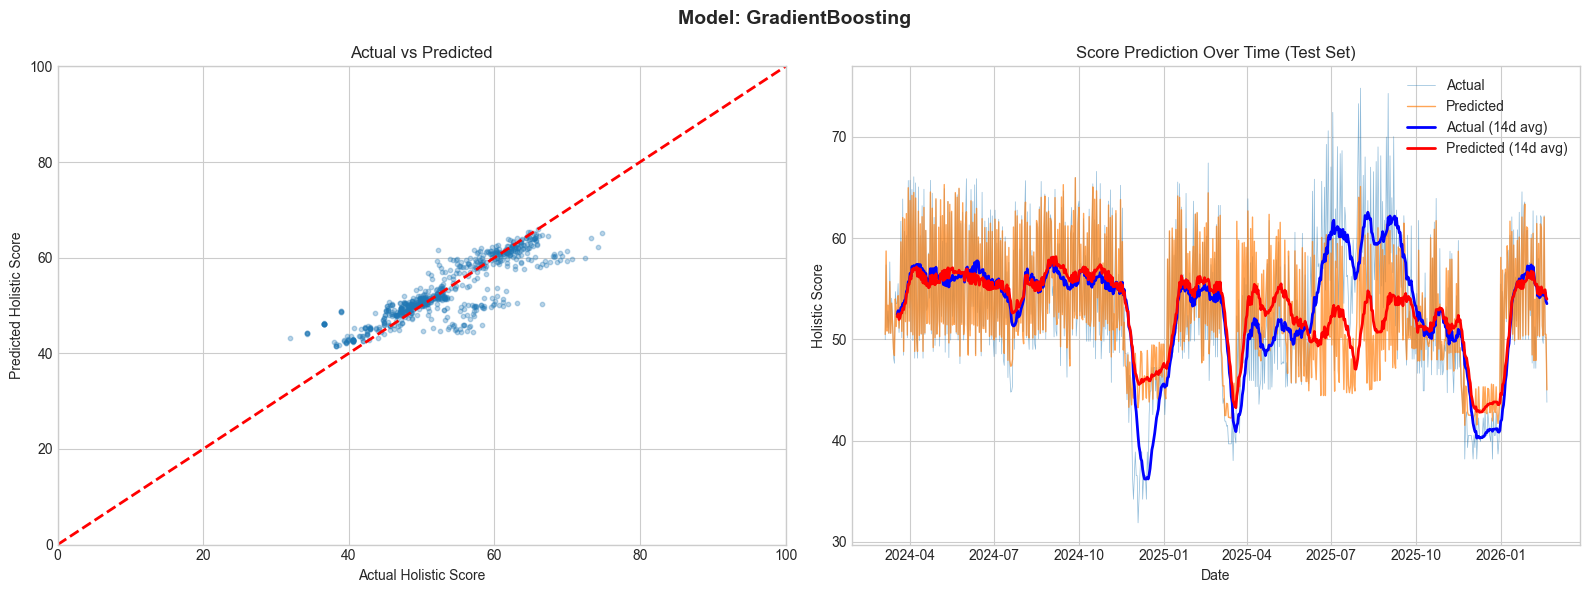

In [7]:
# Train best model on full data
best_model_name = results_df.index[0]
print(f"\nBest model: {best_model_name} (R²={results_df.loc[best_model_name, 'R²']:.3f})")

best_model = models[best_model_name]
final_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', best_model),
])

# 80/20 time split for final evaluation
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

final_pipe.fit(X_train, y_train)
y_pred = final_pipe.predict(X_test)

print(f"\nFinal test (last 20%):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
print(f"  R²:   {r2_score(y_test, y_pred):.3f}")

# Actual vs Predicted plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
ax1.scatter(y_test, y_pred, alpha=0.3, s=10)
ax1.plot([0, 100], [0, 100], 'r--', linewidth=2)
ax1.set_xlabel('Actual Holistic Score')
ax1.set_ylabel('Predicted Holistic Score')
ax1.set_title('Actual vs Predicted')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)

# Time series comparison
ax2.plot(y_test.index, y_test.values, alpha=0.5, label='Actual', linewidth=0.5)
ax2.plot(y_test.index, y_pred, alpha=0.7, label='Predicted', linewidth=1)
actual_roll = pd.Series(y_test.values, index=y_test.index).rolling(14).mean()
pred_roll = pd.Series(y_pred, index=y_test.index).rolling(14).mean()
ax2.plot(actual_roll.index, actual_roll.values, 'b-', linewidth=2, label='Actual (14d avg)')
ax2.plot(pred_roll.index, pred_roll.values, 'r-', linewidth=2, label='Predicted (14d avg)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Holistic Score')
ax2.set_title('Score Prediction Over Time (Test Set)')
ax2.legend()

plt.suptitle(f'Model: {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3: Feature Importance & Explainability

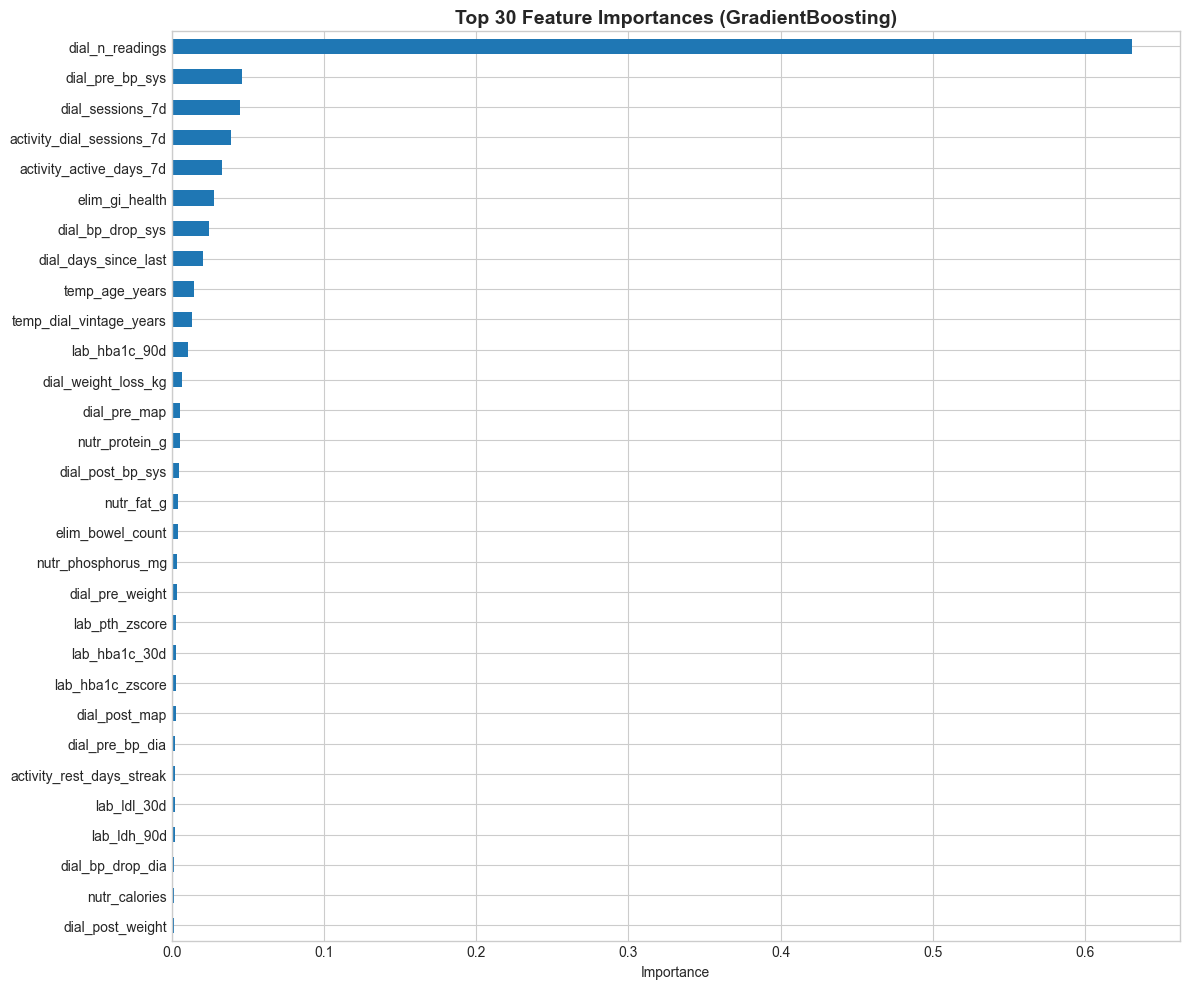

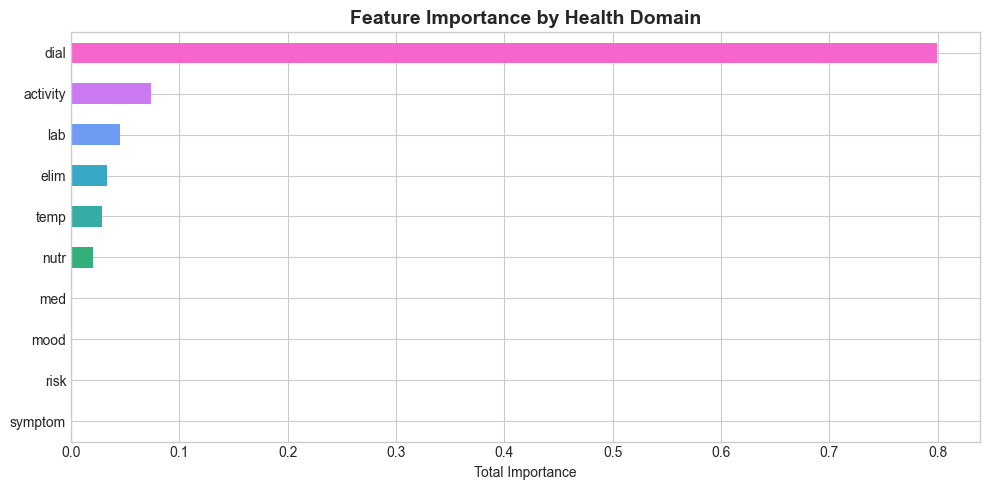

In [8]:
# Retrain on all data for feature importance
final_pipe.fit(X, y)

# Get feature importance
fitted_model = final_pipe.named_steps['model']

if hasattr(fitted_model, 'feature_importances_'):
    importances = fitted_model.feature_importances_
elif hasattr(fitted_model, 'coef_'):
    importances = np.abs(fitted_model.coef_)
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=good_cols).sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    top_n = 30
    feat_imp.head(top_n).plot(kind='barh', ax=ax)
    ax.invert_yaxis()
    ax.set_xlabel('Importance')
    ax.set_title(f'Top {top_n} Feature Importances ({best_model_name})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Group by domain
    domain_imp = {}
    for feat, imp in feat_imp.items():
        domain = feat.split('_')[0]
        domain_imp[domain] = domain_imp.get(domain, 0) + imp
    
    domain_df = pd.Series(domain_imp).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    domain_df.plot(kind='barh', ax=ax, color=sns.color_palette('husl', len(domain_df)))
    ax.set_xlabel('Total Importance')
    ax.set_title('Feature Importance by Health Domain', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

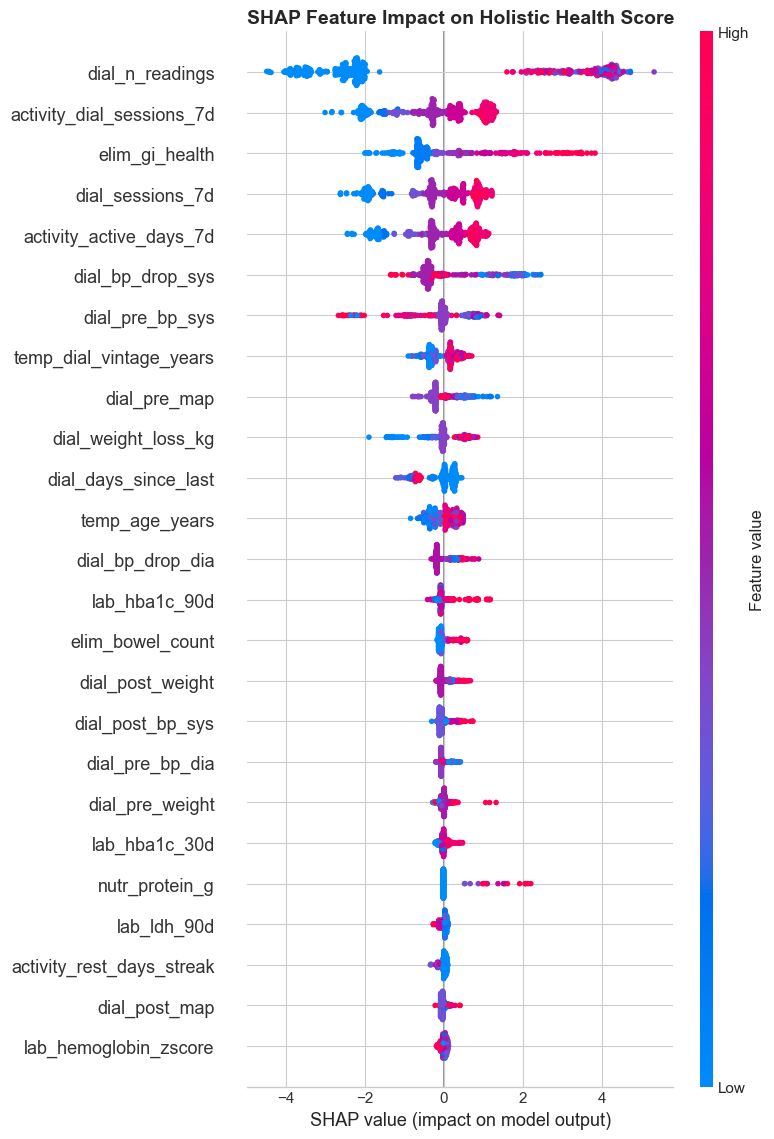

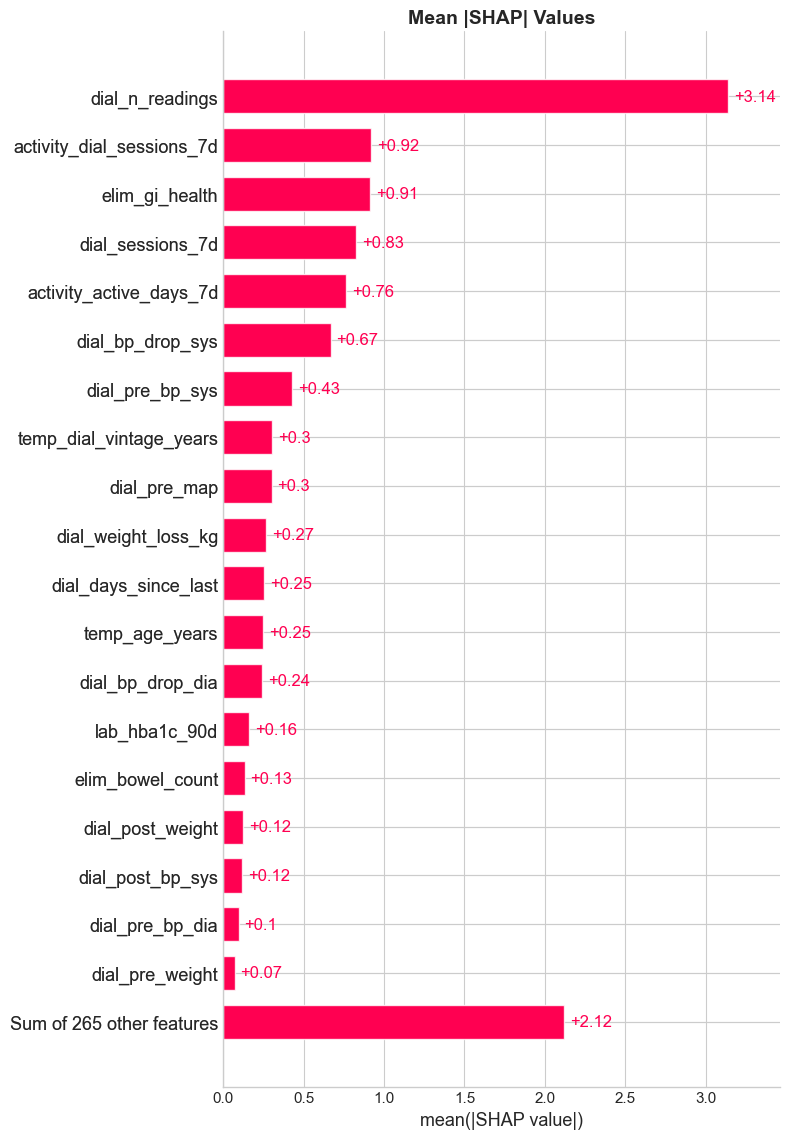

In [9]:
# SHAP analysis (if available)
if HAS_SHAP and hasattr(fitted_model, 'predict'):
    # Preprocess X for SHAP
    X_processed = final_pipe.named_steps['preprocess'].transform(X)
    X_processed_df = pd.DataFrame(X_processed, columns=good_cols, index=X.index)
    
    # Use a sample for speed
    sample_size = min(500, len(X_processed_df))
    X_sample = X_processed_df.sample(sample_size, random_state=42)
    
    explainer = shap.Explainer(fitted_model, X_sample)
    shap_values = explainer(X_sample)
    
    # Summary plot
    fig, ax = plt.subplots(figsize=(12, 10))
    shap.summary_plot(shap_values, X_sample, max_display=25, show=False)
    plt.title('SHAP Feature Impact on Holistic Health Score', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Bar plot
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.plots.bar(shap_values, max_display=20, show=False)
    plt.title('Mean |SHAP| Values', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("SHAP not available. Install with: pip install shap")

---
## Part 4: Risk Prediction Models
Binary classifiers for specific health risks.

In [10]:
# Load risk labels from NB03 (already computed from lab thresholds)
risk_labels_path = FEATURES_DIR / 'risk_labels.csv'
if risk_labels_path.exists():
    risk_labels = pd.read_csv(risk_labels_path, index_col='date', parse_dates=True)
else:
    # Extract risk columns from the feature matrix itself
    risk_cols = [c for c in df.columns if c.startswith('risk_')]
    risk_labels = df[risk_cols].copy()

# Add computed-score-based risk labels
if 'holistic_score' in health_scores.columns:
    risk_labels['risk_poor_health'] = (health_scores['holistic_score'] < 40).astype(int)

# Add composite risks not in NB03
if 'dial_weight_loss_kg' in df.columns:
    risk_labels['risk_fluid_overload'] = (df['dial_weight_loss_kg'] > 4).astype(int)

if 'dial_bp_drop_sys' in df.columns:
    risk_labels['risk_intradialytic_hypotension'] = (df['dial_bp_drop_sys'] > 30).astype(int)

if 'elim_vomit_count' in df.columns and 'elim_bowel_count' in df.columns:
    risk_labels['risk_gi_distress'] = (
        (df['elim_vomit_count'] > 0) | (df['elim_bowel_count'] > 4)
    ).astype(int)

print("Risk labels available:")
print("=" * 60)
for col in sorted(risk_labels.columns):
    total = risk_labels[col].notna().sum()
    pos = risk_labels[col].sum()
    pct = pos / total * 100 if total > 0 else 0
    print(f"  {col:38s} {int(pos):>5} / {total:>5} positive ({pct:.1f}%)")

Risk labels available:
  risk_anemia                             1816 /  3417 positive (53.1%)
  risk_fluid_overload                        9 /  3586 positive (0.3%)
  risk_gi_distress                        1024 /  3586 positive (28.6%)
  risk_hyperkalemia                        364 /  3395 positive (10.7%)
  risk_hyperparathyroid                   3001 /  3552 positive (84.5%)
  risk_hyperphosphatemia                     0 /   192 positive (0.0%)
  risk_hypocalcemia                        259 /  3304 positive (7.8%)
  risk_hypokalemia                         422 /  3395 positive (12.4%)
  risk_inadequate_dial                       4 /    21 positive (19.0%)
  risk_intradialytic_hypotension           238 /  3586 positive (6.6%)
  risk_iron_deficiency                     717 /  3386 positive (21.2%)
  risk_liver_stress                          0 /  1360 positive (0.0%)
  risk_malnutrition                        124 /  3395 positive (3.7%)
  risk_metabolic_acidosis                  313 

In [11]:
# Train a risk classifier for each risk label
risk_results = {}

for risk_col in sorted(risk_labels.columns):
    y_risk = risk_labels[risk_col].dropna()
    # Align with our feature matrix
    common_idx = X.index.intersection(y_risk.index)
    X_risk = X.loc[common_idx]
    y_risk = y_risk.loc[common_idx]
    
    if y_risk.sum() < 10:
        print(f"  ⚠️  {risk_col}: {int(y_risk.sum())} positives — skipping (need ≥10)")
        continue
    
    if (y_risk == 0).sum() < 10:
        print(f"  ⚠️  {risk_col}: {int((y_risk==0).sum())} negatives — skipping (need ≥10)")
        continue
    
    clf_pipe = Pipeline([
        ('preprocess', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler()),
        ])),
        ('model', RandomForestClassifier(
            n_estimators=200, max_depth=8, class_weight='balanced',
            random_state=42, n_jobs=-1
        )),
    ])
    
    # Time-series split
    split = int(len(X_risk) * 0.8)
    X_tr, X_te = X_risk.iloc[:split], X_risk.iloc[split:]
    y_tr, y_te = y_risk.iloc[:split], y_risk.iloc[split:]
    
    clf_pipe.fit(X_tr, y_tr)
    y_prob = clf_pipe.predict_proba(X_te)[:, 1]
    y_pred = clf_pipe.predict(X_te)
    
    try:
        auc = roc_auc_score(y_te, y_prob)
    except ValueError:
        auc = 0.5
    
    risk_results[risk_col] = {
        'AUC': auc,
        'Accuracy': (y_pred == y_te).mean(),
        'Positives': int(y_risk.sum()),
        'pipeline': clf_pipe,
    }
    print(f"  {risk_col:38s} AUC={auc:.3f}  Acc={float((y_pred == y_te).mean()):.3f}  (+:{int(y_risk.sum())})")

risk_df = pd.DataFrame({
    k: {kk: vv for kk, vv in v.items() if kk != 'pipeline'} 
    for k, v in risk_results.items()
}).T.sort_values('AUC', ascending=False)
print("\n" + "=" * 60)
print(risk_df.to_string())

  risk_anemia                            AUC=1.000  Acc=1.000  (+:1816)
  ⚠️  risk_fluid_overload: 9 positives — skipping (need ≥10)
  risk_gi_distress                       AUC=1.000  Acc=0.919  (+:1024)
  risk_hyperkalemia                      AUC=1.000  Acc=0.978  (+:364)
  risk_hyperparathyroid                  AUC=1.000  Acc=0.602  (+:3001)
  ⚠️  risk_hyperphosphatemia: 0 positives — skipping (need ≥10)
  risk_hypocalcemia                      AUC=1.000  Acc=0.930  (+:259)
  risk_hypokalemia                       AUC=1.000  Acc=0.994  (+:422)
  ⚠️  risk_inadequate_dial: 4 positives — skipping (need ≥10)
  risk_intradialytic_hypotension         AUC=1.000  Acc=0.968  (+:238)
  risk_iron_deficiency                   AUC=1.000  Acc=0.717  (+:717)
  ⚠️  risk_liver_stress: 0 positives — skipping (need ≥10)
  risk_malnutrition                      AUC=0.997  Acc=0.866  (+:124)
  risk_metabolic_acidosis                AUC=1.000  Acc=0.893  (+:313)
  risk_poor_health                       

---
## Part 5: Cross-Domain Correlation Discovery

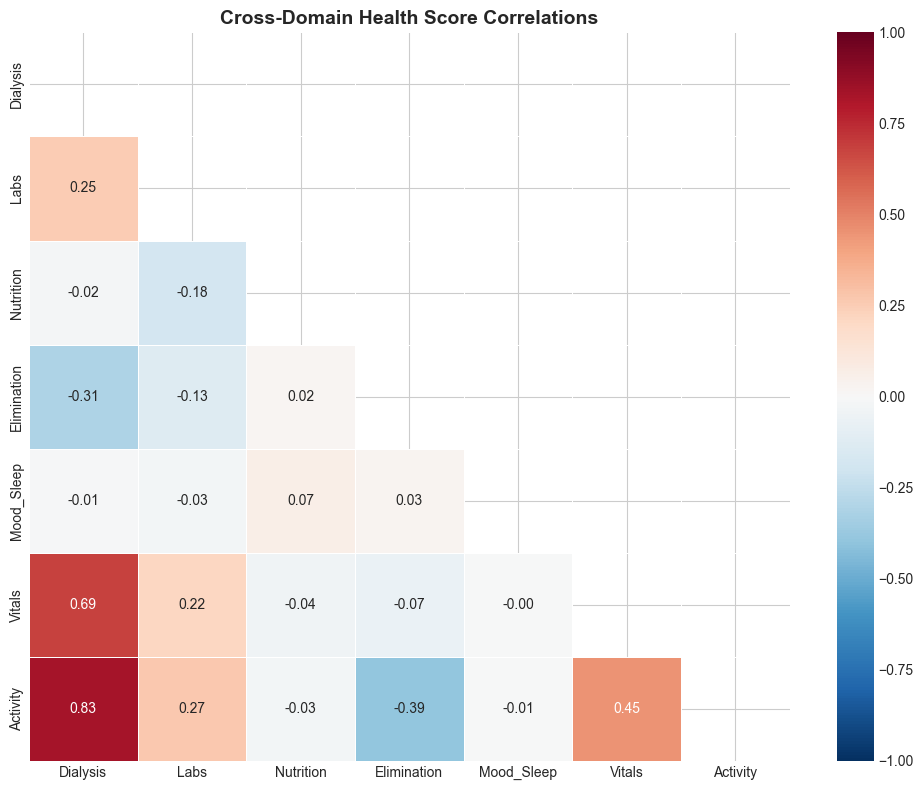


Strongest cross-domain relationships:
  ↑↑ Dialysis        ↔ Activity       : r=0.834
  ↑↑ Dialysis        ↔ Vitals         : r=0.687
  ↑↑ Vitals          ↔ Activity       : r=0.450
  ↑↓ Elimination     ↔ Activity       : r=-0.392
  ↑↓ Dialysis        ↔ Elimination    : r=-0.307
  ↑↑ Labs            ↔ Activity       : r=0.272
  ↑↑ Dialysis        ↔ Labs           : r=0.252
  ↑↑ Labs            ↔ Vitals         : r=0.217
  ↑↓ Labs            ↔ Nutrition      : r=-0.183
  ↑↓ Labs            ↔ Elimination    : r=-0.127


In [12]:
# Compute domain-level correlations using the sub-scores
sub_scores = health_scores[[c for c in health_scores.columns if c.startswith('score_')]]

if sub_scores.shape[1] > 2:
    domain_corr = sub_scores.corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(domain_corr, dtype=bool))
    labels = [c.replace('score_', '').title() for c in domain_corr.columns]
    
    sns.heatmap(domain_corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5)
    ax.set_title('Cross-Domain Health Score Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Extract top correlations
    print("\nStrongest cross-domain relationships:")
    print("=" * 60)
    upper = domain_corr.where(~mask)
    pairs = upper.unstack().dropna().sort_values(key=abs, ascending=False)
    pairs = pairs[pairs.abs() < 1.0]
    
    for (a, b), val in pairs.head(10).items():
        direction = '↑↑' if val > 0 else '↑↓'
        a_name = a.replace('score_', '').title()
        b_name = b.replace('score_', '').title()
        print(f"  {direction} {a_name:15s} ↔ {b_name:15s}: r={val:.3f}")

In [13]:
# Lagged correlations: does today's nutrition affect tomorrow's labs?
print("\nLagged Correlations (does domain A at day T predict domain B at T+N?)")
print("=" * 70)

lag_pairs = [
    ('score_nutrition', 'score_labs', [1, 3, 7, 14, 30]),
    ('score_dialysis', 'score_vitals', [1, 2, 3]),
    ('score_mood_sleep', 'score_dialysis', [1, 3, 7]),
    ('score_fitness', 'score_mood_sleep', [1, 3, 7]),
    ('score_elimination', 'score_nutrition', [1, 3]),
]

for a, b, lags in lag_pairs:
    if a in sub_scores.columns and b in sub_scores.columns:
        a_name = a.replace('score_', '').title()
        b_name = b.replace('score_', '').title()
        print(f"\n  {a_name} → {b_name}:")
        for lag in lags:
            corr = sub_scores[a].corr(sub_scores[b].shift(-lag))
            bar = '█' * int(abs(corr) * 20)
            print(f"    lag {lag:2d}d: r={corr:+.3f} {bar}")


Lagged Correlations (does domain A at day T predict domain B at T+N?)

  Nutrition → Labs:
    lag  1d: r=-0.184 ███
    lag  3d: r=-0.190 ███
    lag  7d: r=-0.189 ███
    lag 14d: r=-0.191 ███
    lag 30d: r=-0.204 ████

  Dialysis → Vitals:
    lag  1d: r=+0.147 ██
    lag  2d: r=+0.373 ███████
    lag  3d: r=+0.284 █████

  Mood_Sleep → Dialysis:
    lag  1d: r=-0.025 
    lag  3d: r=-0.018 
    lag  7d: r=+0.007 

  Elimination → Nutrition:
    lag  1d: r=+0.015 
    lag  3d: r=+0.017 


---
## Part 6: Save Models & Export to Core ML

In [14]:
# ═══════════════════════════════════════════════════
# Save sklearn models
# ═══════════════════════════════════════════════════

# Retrain final model on ALL data for production
final_pipe.fit(X, y)

# Save main holistic health model
model_path = MODELS_DIR / 'holistic_health_model.joblib'
joblib.dump({
    'pipeline': final_pipe,
    'feature_names': good_cols,
    'model_name': best_model_name,
    'metrics': results[best_model_name],
    'trained_at': datetime.now().isoformat(),
    'training_samples': len(X),
    'date_range': f"{df.index.min().date()} to {df.index.max().date()}",
}, model_path)
print(f"✅ Saved holistic model: {model_path}")
print(f"   Size: {model_path.stat().st_size / 1024:.0f} KB")

# Save risk models
for risk_name, risk_data in risk_results.items():
    risk_path = MODELS_DIR / f'{risk_name}_model.joblib'
    risk_data['pipeline'].fit(X.loc[risk_labels[risk_name].dropna().index], 
                              risk_labels[risk_name].dropna())
    joblib.dump({
        'pipeline': risk_data['pipeline'],
        'feature_names': good_cols,
        'auc': risk_data['AUC'],
    }, risk_path)
    print(f"✅ Saved risk model: {risk_path}")

# Save health scores
health_scores.to_csv(FEATURES_DIR / 'health_scores.csv')
print(f"\n✅ Saved health scores: {FEATURES_DIR / 'health_scores.csv'}")

✅ Saved holistic model: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models/holistic_health_model.joblib
   Size: 803 KB
✅ Saved risk model: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models/risk_anemia_model.joblib
✅ Saved risk model: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models/risk_gi_distress_model.joblib
✅ Saved risk model: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models/risk_hyperkalemia_model.joblib
✅ Saved risk model: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models/risk_hyperparathyroid_model.joblib
✅ Saved risk model: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models/risk_hypocalcemia_model.joblib
✅ Saved risk model: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models/risk_hypokalemia_model.joblib
✅ Saved risk model: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models/risk_intradialytic_hypotension_model.joblib
✅ Saved risk model: /Users/woleakpose/Documents/Developer/LAFIAKALO/ML/models/risk_iron_deficiency_mo

In [15]:
# ═══════════════════════════════════════════════════
# Export to Core ML (for on-device Apple inference)
# ═══════════════════════════════════════════════════

if HAS_COREML:
    try:
        # Convert sklearn pipeline to Core ML
        coreml_model = ct.converters.sklearn.convert(
            final_pipe,
            input_features=good_cols,
            output_feature_names='holistic_health_score'
        )
        
        # Add metadata
        coreml_model.author = 'LAFIAKALO Holistic Health ML'
        coreml_model.short_description = (
            'Predicts holistic health score (0-100) from multi-domain health features '
            'including dialysis, labs, nutrition, elimination, medications, mood, vitals, and fitness.'
        )
        coreml_model.version = '1.0'
        coreml_model.license = 'Private - LAFIAKALO'
        
        # Input descriptions
        spec = coreml_model.get_spec()
        
        coreml_path = MODELS_DIR / 'HolisticHealthModel.mlmodel'
        coreml_model.save(str(coreml_path))
        print(f"✅ Core ML model saved: {coreml_path}")
        print(f"   Size: {coreml_path.stat().st_size / 1024:.0f} KB")
        print(f"   Inputs: {len(good_cols)} features")
        print(f"   Output: holistic_health_score (Double)")
        
    except Exception as e:
        print(f"⚠️  Core ML conversion failed: {e}")
        print("   This may require a tree-based or linear model. Trying with a Ridge model...")
        
        # Fallback: train a linear model for Core ML
        linear_pipe = Pipeline([
            ('preprocess', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler()),
            ])),
            ('model', Ridge(alpha=1.0)),
        ])
        linear_pipe.fit(X, y)
        
        try:
            coreml_model = ct.converters.sklearn.convert(
                linear_pipe,
                input_features=good_cols,
                output_feature_names='holistic_health_score'
            )
            coreml_model.author = 'LAFIAKALO Holistic Health ML'
            coreml_model.short_description = 'Linear holistic health score predictor'
            coreml_model.version = '1.0'
            
            coreml_path = MODELS_DIR / 'HolisticHealthModel.mlmodel'
            coreml_model.save(str(coreml_path))
            print(f"✅ Core ML model saved (linear fallback): {coreml_path}")
        except Exception as e2:
            print(f"❌ Core ML conversion failed: {e2}")
else:
    print("⚠️  coremltools not installed. Install with: pip install coremltools")
    print("   The .joblib model can still be used in Python.")

⚠️  Core ML conversion failed: name '_tree' is not defined
   This may require a tree-based or linear model. Trying with a Ridge model...
❌ Core ML conversion failed: name '_tree' is not defined


---
## Part 7: Summary & Next Steps

In [16]:
print("\n" + "="*70)
print("🧠 HOLISTIC HEALTH MODEL — TRAINING COMPLETE")
print("="*70)

print(f"\n📊 DATA")
print(f"   Training samples:   {len(X):,} days")
print(f"   Features:           {len(good_cols)}")
print(f"   Date range:         {df.index.min().date()} → {df.index.max().date()}")
print(f"   Span:               {(df.index.max() - df.index.min()).days:,} days")

print(f"\n🎯 HOLISTIC HEALTH SCORE MODEL")
print(f"   Algorithm:          {best_model_name}")
for metric, val in results[best_model_name].items():
    print(f"   {metric}:{'':>{15-len(metric)}} {val:.3f}")

print(f"\n⚠️  RISK MODELS")
for risk, data in risk_results.items():
    print(f"   {risk:30s} AUC={data['AUC']:.3f}")

print(f"\n💾 SAVED ARTIFACTS")
for f in sorted(MODELS_DIR.glob('*')):
    size = f.stat().st_size / 1024
    print(f"   {f.name:40s} {size:>8.0f} KB")

print(f"\n🔮 NEXT STEPS")
print(f"   1. Drop your Excel/JSON/PDF data into ML/data/raw/ and re-run all notebooks")
print(f"   2. Fine-tune renal diet thresholds in the scoring function")
print(f"   3. Add the .mlmodel to your iOS app for on-device inference")
print(f"   4. Set up periodic re-training as new data comes in")
print(f"   5. Explore time-series forecasting for lab value prediction")


🧠 HOLISTIC HEALTH MODEL — TRAINING COMPLETE

📊 DATA
   Training samples:   3,586 days
   Features:           284
   Date range:         2016-04-28 → 2026-02-20
   Span:               3,585 days

🎯 HOLISTIC HEALTH SCORE MODEL
   Algorithm:          GradientBoosting
   RMSE:            2.736
   MAE:             2.045
   R²:              0.832

⚠️  RISK MODELS
   risk_anemia                    AUC=1.000
   risk_gi_distress               AUC=1.000
   risk_hyperkalemia              AUC=1.000
   risk_hyperparathyroid          AUC=1.000
   risk_hypocalcemia              AUC=1.000
   risk_hypokalemia               AUC=1.000
   risk_intradialytic_hypotension AUC=1.000
   risk_iron_deficiency           AUC=1.000
   risk_malnutrition              AUC=0.997
   risk_metabolic_acidosis        AUC=1.000
   risk_poor_health               AUC=0.965

💾 SAVED ARTIFACTS
   HEBCS_pathway_definitions.json                 11 KB
   clinical_risk                                   0 KB
   holistic_health_model